<font size=5>Mix-n-match: Optimization, X-ray Scattering, and AFM   
Goals:  
1. Least-squares fitting - what function are we minimizing?  
2. X-ray scattering: simulating & setting up a least-squares fit, fitting $R$ and $R_{g}$ in the Guinier region$  
3. AFM - different ways to analyze a phase-separated material

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import cm

!git clone https://github.com/cbishop4/MSE7530.git

Cloning into 'MSE7530'...
remote: Enumerating objects: 993, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 993 (delta 104), reused 62 (delta 62), pack-reused 865 (from 1)
Receiving objects: 100% (993/993), 165.20 MiB | 21.61 MiB/s, done.
Resolving deltas: 100% (382/382), done.
Updating files: 100% (356/356), done.


In [2]:

from scipy.optimize import curve_fit

## Stretched Exponential  
A stretched exponential function is often used as a phenomenological description of relaxation in disordered systems. Later in the semester, we will return to X-rays, specifically X-ray photon correlation spectroscopy.  

Start with a user-defined function. A stretched exponential function is represented by  
<font size=5>$f(t) = Ae^{-(\frac{t}{\tau_{KWW}})^{\beta}} + C$  
</font>Where $f(t)$ corresponds to some measured property at time $t$,  
$t$ is the time past $t_0$,  
$\tau_{KWW}$ is a characteristic relaxation time that is usually what we are solving for,  
$\beta$ is a stretching exponent that is a measure of how *heterogeneous* the dynamics are (and can also be somewhat nebulous),  
$A$ is the value of the property at $t_0$,  
and $C$ is the value of the property at infinite $t$.

### Creating a dictionary
We will use a dictionary, a built-in Python data type, to hold the data for how the structure evolves in Polylactic Acid Glasses. Data is from T. Bennin et. al., "Enhanced Segmental Dynamics of Poly(lactic acid) Glasses during Constant Strain Rate Deformation", *Macromolecules* 52 (17): 6428-6437 (2019). https://doi.org/10.1021/acs.macromol.9b01363

In [3]:
temps = [315, 317, 320, 323]
decays = {}
for T in temps:
  data = pd.read_csv(f'/content/MSE7530/sampledata/{T}K.csv', header=None, names=['t','I'])
  decays[T] = data

We have created a dictionary that holds 4 dataframes as **values**; there is a separate **key** that corresponds to each value. In this case, our keys are integers. They can be any data type, and are often strings.

### Constraining from the function

In [4]:
def KWW2(time, tau):
  ''' A stretched exponential function.
    Args:
      time (float) : time past t_0
      A (float) : value of property at t=0
      tau (float) : characteristic relaxation time
      beta (float) : stretching exponent
      C (float) : value of property at infinite time
    Returns:
      A * np.exp(-(time/tau)**beta) + C (float) : value of property at time
  '''
  beta = 0.5
  C = 0.0
  A = 1.0
  return A * np.exp(-(time/tau)**beta) + C

In [5]:
popt, pcov = curve_fit(KWW2, decays[323]['t'], decays[323]['I'])

pcov is the covariance matrix. Its diagonals provide the variance of the parameter estimate and allow you to compute standard deviation errors; we will do this later. For now, let's focus on popt, which is the optimal parameters.

#### Solving for all 4 $\tau$

<font color=blue>Run through this for all 4 using the dictionary. We will do this together. Finish with a plot of $\tau$ vs. Temperature.

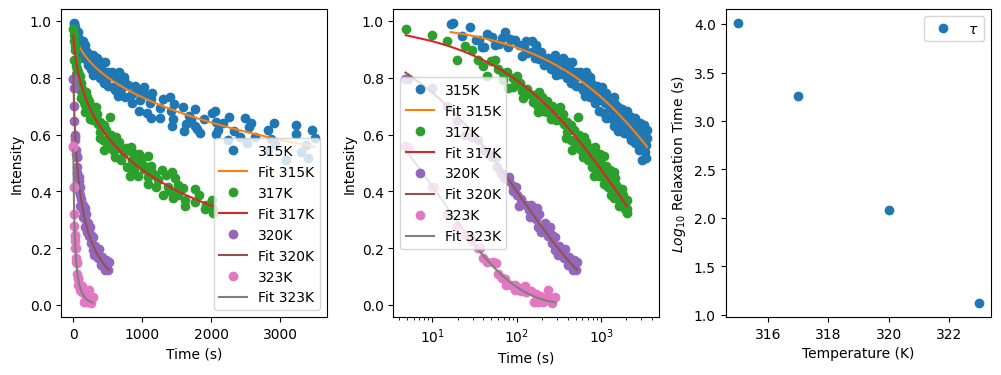

In [6]:
fig, ax = plt.subplots(1,3,figsize=(12,4))
plt.subplots_adjust(wspace=0.25)
taus = []
for k in decays.keys():
  popt, pcov = curve_fit(KWW2, decays[k]['t'], decays[k]['I'])
  ax[0].plot(decays[k]['t'],decays[k]['I'],'o',label=f'{k}K')
  ax[0].plot(decays[k]['t'],KWW2(decays[k]['t'],*popt),label=f'Fit {k}K')
  ax[1].plot(decays[k]['t'],decays[k]['I'],'o',label=f'{k}K')
  ax[1].plot(decays[k]['t'],KWW2(decays[k]['t'],*popt),label=f'Fit {k}K')
  taus.append(popt[0])
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Intensity')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Intensity')



taus = np.asarray(taus)
ax[2].plot(decays.keys(),np.log10(taus),'o',label=r'$\tau$')
ax[2].set_xlabel('Temperature (K)')
ax[2].set_ylabel('$Log_{10}$ Relaxation Time (s)')
ax[1].semilogx()

for a in ax:
  a.legend()

### Questions/exercises  
1. Calculate the residual sum of squares for each fit. How would you do this? Discuss as a class. Implement in code if you are able, otherwise leave for a home exercise.  
2. There are also alternate ways to constrain the fitting using bounds. We will briefly address this in class, and I will include them in an at-home exercise.

### Answer: calculating residual sum of squares  
High-level: for each **data point**, calculate the difference between it and the fit. Square it. Sum this up for every data point, and then take the square root of the entire result.

Example for a single data point:

First, we need to know what the optimal parameter for our function is. Let's start with 315 K. Here we will refit to find our value of $\tau$.

In [7]:
k = 315 # setting this as a variable so it's easier to automate later
popt, pcov = curve_fit(KWW2, decays[k]['t'], decays[k]['I'])
print(f'Our value of tau is {popt[0]} s for {k} K')

Our value of tau is 10231.612105159016 s for 315 K


Now, we'll calculate the squared residual at a single point. The formula for this is  
$(I_{data} - I_{model})^{2}$  
The formula given in lecture had coefficients $w_1, w_2,$ etc. We assume these to be 1 for all at this point; we may explicitly weight later.

In [8]:
# showing the dataframe as a reminder
decays[k]

,t,I
0,16.485668,0.990173
1,17.699871,0.992139
2,22.201920,0.946471
3,27.761265,0.978226
4,33.158749,0.931761
...,...,...
119,3308.145719,0.537551
120,3376.320096,0.564924
121,3411.156794,0.516777
122,3464.086955,0.615573


In [9]:
decays[k].iloc[3]
# here I will explicitly set the time and Intensity at that time as variables
t_data = decays[k].iloc[3]['t']
I_data = decays[k].iloc[3]['I']
I_model = KWW2(t_data, *popt)
print(f'I_model is {I_model}, and I_data is {I_data}')

I_model is 0.9492442012819902, and I_data is 0.9782257777777776


Now, we calculate the difference squared:

In [10]:
res = (I_data - I_model)**2
print(f'Our residual squared is {res}')

Our residual squared is 0.0008399317761811811


Now, we could make a loop to do this for every point, as below:

In [11]:
import time

t0 = time.time()

running_sum = 0 # initialize something to hold your quantity
for row in decays[315].iterrows():
  t_data = row[1]['t']
  I_data = row[1]['I']
  I_model = KWW2(t_data, *popt)
  running_sum = running_sum + (I_data - I_model)**2
rsum = running_sum**0.5
print(f'Our residual sum is {rsum}; this calculation took {time.time() - t0} seconds')

Our residual sum is 0.33369575012257463; this calculation took 0.006607770919799805 seconds


We could also have done this with numpy arrays as follows:

In [12]:
t0 = time.time()

times = np.asarray(decays[k]['t'])
I_datas = np.asarray(decays[k]['I'])
I_models = KWW2(times, *popt)
rsum = np.sum((I_datas - I_models)**2)**0.5
print(f'Our residual sum is {rsum}; this calculation took {time.time() - t0} seconds')

Our residual sum is 0.3336957501225746; this calculation took 0.0006544589996337891 seconds


While it's essentially meaningless for something so quick, using the numpy arrays gave us a 10x speedup.

In [13]:
type(temps)

list

#### Quickly summing for each


In [14]:
Tnps = np.asarray(temps)
rsums = []
for k in decays.keys():
  times = np.asarray(decays[k]['t'])
  I_datas = np.asarray(decays[k]['I'])
  I_models = KWW2(times, *popt)
  rsum = np.sum((I_datas - I_models)**2)**0.5
  rsums.append(rsum)
rsums = np.asarray(rsums)


Text(0, 0.5, 'Residual Sum')

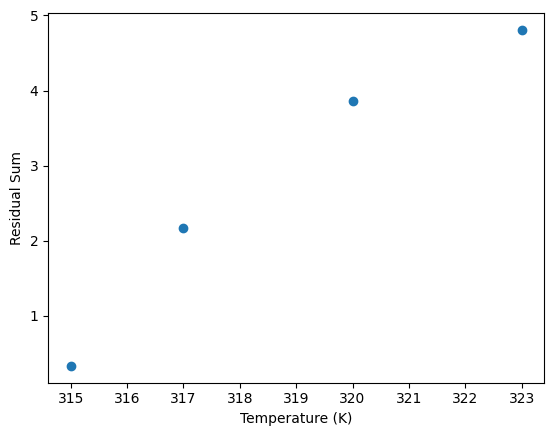

In [15]:
plt.plot(Tnps,rsums,'o')
plt.xlabel('Temperature (K)')
plt.ylabel('Residual Sum')

Is this model worse and worse at higher temperatures? Why or why not?

### Mathematical equivalence

Text(0, 0.5, 'Residual Sum')

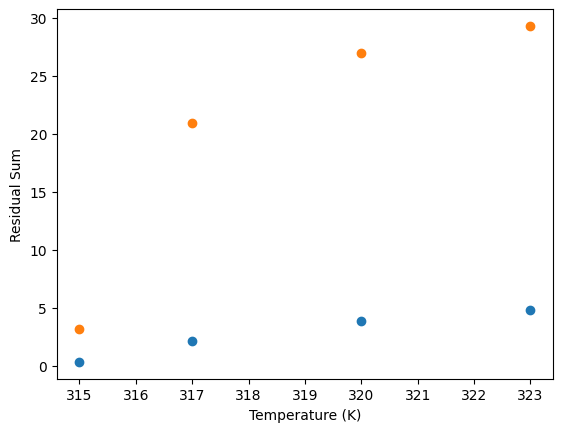

In [16]:
Tnps = np.asarray(temps)
rsums_real = []
rsum_test1 = []
for k in decays.keys():
  times = np.asarray(decays[k]['t'])
  I_datas = np.asarray(decays[k]['I'])
  I_models = KWW2(times, *popt)
  rsum = np.sum((I_datas - I_models)**2)**0.5
  rsums_real.append(rsum)
  rsum2 = np.sum(((I_datas - I_models)**2)**0.5)
  rsum_test1.append(rsum2)
rsums_real = np.asarray(rsums_real)
rsum_test1 = np.asarray(rsum_test1)
plt.plot(Tnps,rsums_real,'o')
plt.plot(Tnps,rsum_test1,'o')
plt.xlabel('Temperature (K)')
plt.ylabel('Residual Sum')

### Least-squares fitting - minimizing the cost function **for parameters**

In [17]:
k = 315 # setting this as a variable so it's easier to automate later
popt, pcov = curve_fit(KWW2, decays[k]['t'], decays[k]['I'])
print(f'Our value of tau is {popt[0]} s for {k} K')

Our value of tau is 10231.612105159016 s for 315 K


In [18]:
test_taus = np.linspace(800, 20000, 1001)
rsums = []
times = np.asarray(decays[k]['t'])
I_datas = np.asarray(decays[k]['I'])
for tt in test_taus:
  I_models = KWW2(times, tt)
  rsum = np.sum((I_datas - I_models)**2)**0.5
  rsums.append(rsum)
rsums = np.asarray(rsums)

Text(0.5, 1.0, 'Goodness of model fit with variable $\\tau$')

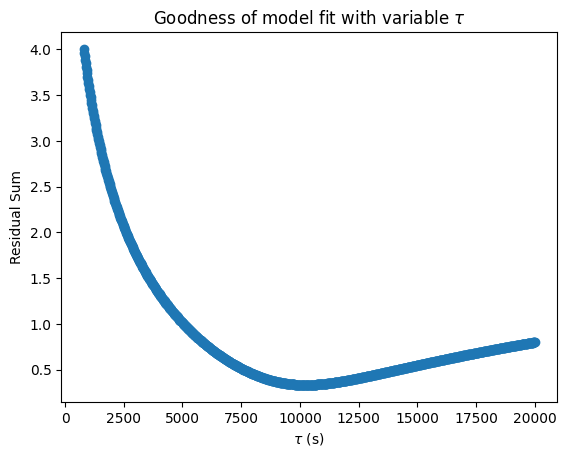

In [19]:
plt.plot(test_taus, rsums,'o')
plt.xlabel(r'$\tau$ (s)')
plt.ylabel('Residual Sum')
plt.title(r'Goodness of model fit with variable $\tau$')

Above, we have minimized the **cost function**

/tmp/ipykernel_2707/2215590584.py:15: RuntimeWarning: divide by zero encountered in divide
  return A * np.exp(-(time/tau)**beta) + C


[]

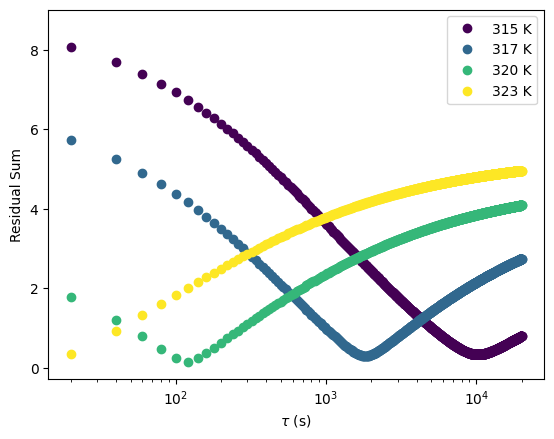

In [20]:
fig, ax = plt.subplots()
test_taus = np.linspace(0., 20000, 1001)
pcol = iter(cm.viridis(np.linspace(0,1,4)))
for k in decays.keys():
  rsums = []
  times = np.asarray(decays[k]['t'])
  I_datas = np.asarray(decays[k]['I'])
  for tt in test_taus:
    I_models = KWW2(times, tt)
    rsum = np.sum((I_datas - I_models)**2)**0.5
    rsums.append(rsum)
  rsums = np.asarray(rsums)
  ax.plot(test_taus, rsums,'o',label=f'{k} K',color=next(pcol))
ax.legend()
ax.set_xlabel(r'$\tau$ (s)')
ax.set_ylabel('Residual Sum')
ax.semilogx()

[]

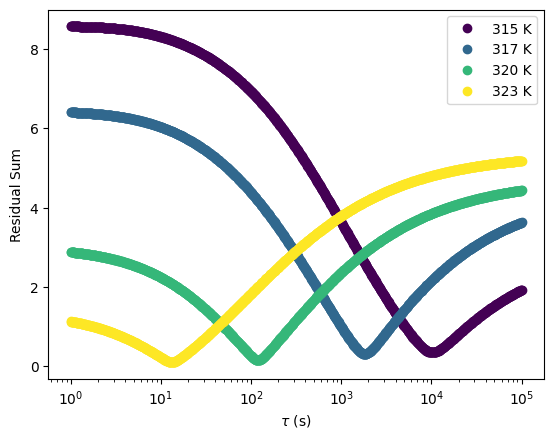

In [21]:
fig, ax = plt.subplots()
test_taus = np.logspace(0., 5., 1001)
pcol = iter(cm.viridis(np.linspace(0,1,4)))
for k in decays.keys():
  rsums = []
  times = np.asarray(decays[k]['t'])
  I_datas = np.asarray(decays[k]['I'])
  for tt in test_taus:
    I_models = KWW2(times, tt)
    rsum = np.sum((I_datas - I_models)**2)**0.5
    rsums.append(rsum)
  rsums = np.asarray(rsums)
  ax.plot(test_taus, rsums,'o',label=f'{k} K',color=next(pcol))
ax.legend()
ax.set_xlabel(r'$\tau$ (s)')
ax.set_ylabel('Residual Sum')
ax.semilogx()

# X-ray Scattering from Liquids and Glasses

### scipy.special

SciPy has many scientific equations pre-loaded to make our lives easier. Take, for example, equation 4.23 in Als-Nielsen & McMorrow for scattering from a sphere of radius r.

<font size=4>$\mathcal{F}(Q) = \frac{1}{V_{p}}\int_0^R\int_0^{2\pi}\int_0^\pi e^{iQrcos~\theta}r^{2}sin~\theta d\theta d\phi dr$  


<font size=4>$ = \frac{1}{V_{p}}\int_0^R 4\pi \frac{sin(Qr)}{Qr}r^2dr$  


<font size=5>$ = 3[\frac{sin(QR) - QRcos(QR)}{Q^{3}R^{3}}] \equiv \frac{3J_{1}(QR)}{QR}$

<font size=4>Where $J_{1}(x)$ is the Bessel function of the first kind. Bessel functions are solutions to Bessel's ordinary differential equation.  They are often used when solving problems in cylindrical and spherical systems. Therefore, they show up often in scientific computing and SciPy has them built in. First,


```
from scipy import special
```



In [ ]:
from scipy import special

## Analytical scattering from perfect shapes in infinitely dilute solutions

In [ ]:
# def FQ2_sphere(radius, q): # scipy Bessel function is not reproducing correct result; what's happening?
#   return (3*special.jv(1,q*radius) / (q*radius))**2
def FQ2_sphere(radius, q):
  return (3*((np.sin(q*radius)- q*radius*np.cos(q*radius)))/(q**3 * radius**3))**2
def FQ2_disc(radius, q):
  return 2 * (1 - (special.jv(1,2*q*radius)/(q*radius)) ) / (q**2 * radius**2)
def FQ2_rod(length, q):
  term1 = (2*special.sici(q*length)[0]) / (q * length)
  term2 = (4 * (np.sin(q*length/2))**2) / (q**2 * length**2)
  return term1 - term2 # I just broke this into two terms to avoid a huge return line

### Form factor scattering from different shapes

In [ ]:
dimension = 100.
qrange = np.linspace(0.0001, 0.2,1000)
fig, ax = plt.subplots()

ax.plot(qrange, FQ2_sphere(dimension,qrange),label='Sphere')
ax.plot(qrange, FQ2_disc(dimension,qrange),label='Disc')
ax.plot(qrange, FQ2_rod(dimension,qrange),label='Rod')
ax.legend()
ax.set_xlabel('Q ($A^{-1}$)')
ax.set_ylabel('$|F(Q)|^{2}$')
ax.set_title('Form factor scattering from different shapes')

Note that the above is a bit different than what's in the book; below we use the table to convert the x-axis to $QR_{g}$ like the figure in the book

In [ ]:
dimension = 100.
qrange = np.linspace(0.0001, .8,1000) # make the q-range a bit longer
QRg_sph = qrange*dimension*(3/5)**.5 # note the 3 different formulas for Rg in the table
QRg_disc = qrange*dimension*(0.5)**0.5
QRg_rod = qrange*dimension*(1/12)**0.5
fig, ax = plt.subplots()
ax.plot(QRg_sph, FQ2_sphere(dimension,qrange),label='Sphere')
ax.plot(QRg_disc, FQ2_disc(dimension,qrange),label='Disc')
ax.plot(QRg_rod, FQ2_rod(dimension,qrange),label='Rod')
ax.legend()
ax.set_xlabel('Q$R_{g}$')
ax.set_ylabel('$|F(Q)|^{2}$')
ax.set_xlim(0,10); ax.set_ylim(0,1.1)

## Effect of radius on the form factor for spheres

In [ ]:
from matplotlib.pyplot import cm
fig, ax = plt.subplots(1,3,figsize=(15,5))
qrange = np.linspace(0.0001, .5,1000)
radii = [50., 100., 150., 200.]
pcol = iter(cm.viridis(np.linspace(0.,.9,len(radii))))
for r in radii:
  cc = next(pcol)
  ax[0].plot(qrange, FQ2_sphere(r,qrange),label=r,color=cc,linewidth=2)
  ax[1].plot(qrange, FQ2_disc(r,qrange),label=r,color=cc,linewidth=2)
  ax[2].plot(qrange, FQ2_rod(r,qrange),label=r,color=cc,linewidth=2)

for a in ax:
  a.semilogy()
  a.legend(title='Dimension (A)')
  a.set_xlabel('Q ($A^{-1}$)')
  a.set_ylabel('$|F(Q)|^{2}$')
ax[0].set_title('Sphere (radius)'); ax[1].set_title('Disc (radius)'); ax[2].set_title('Rod (length)')

### In-class 1: For a sphere, find the fringe spacing for each particle radius in $Å^{-1}$. What is the relationship?  
The below will allow you to do this for one at a time. Hint: ax.axvline(value) can let you draw lines on the fringe spacings. You can copy-paste this for different values of the radius to keep your work.

In [ ]:
fig, ax = plt.subplots()
qrange = np.linspace(0.0001, .5,1000)
radius = 10.

ax.plot(qrange, FQ2_sphere(radius,qrange),label=radius,linewidth=2)


ax.semilogy()
ax.legend(title='Dimension (A)')
ax.set_xlabel('Q ($A^{-1}$)')
ax.set_ylabel('$|F(Q)|^{2}$')
ax.set_title(f'Form Factor scattering for dilute sphere with radius {radius} $A^-1$')

## Guinier Analysis

<font size=4> Let's pull out the Rgs by Guinier analysis and compare to the dimensions we made the curves with. To do this we will need to:  
1. Change the axes to be appropriate for Guinier analysis  
2. Identify the proper range in which the Guinier approximation holds
3. Linearly fit the data and find the slope; compare with the known Rg

### Guinier analysis

#### Example 1: Sphere with dimension 100.0 Angstroms

Step 1: Calculate "experimental" scattering and transform axes

In [ ]:
# calculate the scattering for the sphere with R = 100.0 Angstroms.
# we will call this the "experimental scattering"
fig, ax = plt.subplots(1,3,figsize=(15,5))
qrange = np.linspace(0.0001, .5,1000)
r = 100.0
experimental_FQ2 = FQ2_sphere(r,qrange)
ax[0].plot(qrange, experimental_FQ2,label=r)
ax[0].set_xlabel('Q ($A^{-1}$)'); ax[0].set_ylabel('$|F(Q)|^{2}$')
# to do Guinier analysis, we need to plot on an ln I vs Q^2 plot
q2 = qrange**2
lnI = np.log(experimental_FQ2) # note that "np.log" is the natural log, while np.log10 is the base 10 log
for a in [ax[1],ax[2]]:
  a.plot(q2,lnI,label=r)
  a.set_xlabel('$Q^{2}~(A^{-2})$'); ax[1].set_ylabel('ln($|F(Q)|^{2}$)')

ax[2].set_xlim(0, 0.005)
ax[0].set_title('Linear plot'); ax[1].set_title('Transformed axes for Guinier analysis')
ax[2].set_title('Zoom-in of plot 2')



Step 2. Identify Guinier range. By visual inspection, it seems clear that by $Q^{2} = 0.002 A^{-2}$, we are well-past a linear regime. What $QR$ does this correspond to? Let's also identify a "safely" linear regime, which we'll say ends at 0.001.

In [ ]:
print(f' Linear approximation ends around {0.001 * r} to {0.002 * r}QR')

Since no explicit value of QR is given in the textbook, this is a decent number for us to see. Keep it in mind for the future and see if it always holds (I'm not sure).

Step 3. Linear Fit.  
Here we will use the scipy.stats linear regression function. There are several different ways you can do linear fits in Python, but this one is good because it gives statistics.

In [ ]:
# import the stats module where linregress is
from scipy import stats

In [ ]:
# first we need to cut our range to the purely linear regime
linear_indices = np.where(q2 < 0.001)
linear_q2 = q2[linear_indices]
linear_lnI = lnI[linear_indices]
plt.plot(linear_q2,linear_lnI,'o')

We can see that this is not exactly linear the whole way through; maybe we want to use a smaller range. Exactly how small you cut it, in reality, depends on your data density.

In [ ]:
lin_result = stats.linregress(linear_q2,linear_lnI)
lin_result

Now we convert to R using the relationship that for a **sphere** the slope of the $ln I$ vs. $Q^{2}$ plot is equal to $-\frac{R^{2}}{5}$

In [ ]:
slope = lin_result[0]
R = np.sqrt(-5 * slope)
R

We got out a value for R that is 107.8 Angstroms, which is roughly the radius that we used to generate the data. Perhaps the disagreement is due to the non-linearity we saw as we got near 0.001; let's try cutting it at 0.0002

Note that the slope is equal to **R**, not **Rg**. To convert the slope to Rg (in the case of an idealized particle) use the formulae provided in table 4.2.

In [ ]:
linear_indices = np.where(q2 < 0.0002)
linear_q2 = q2[linear_indices]
linear_lnI = lnI[linear_indices]
plt.plot(linear_q2,linear_lnI,'o')
lin_result = stats.linregress(linear_q2,linear_lnI)
lin_result
slope = lin_result[0]
R = np.sqrt(-5 * slope)
print(R)

Now R is equal to 101 Angstroms, which is pretty close to our particle radius. Here I will make an equation to automatically return the slope so we can see the effect of cutting that regime.

In [ ]:
def find_slope_sphere(qmax, q_square, ln_I):
  linear_indices = np.where(q_square < qmax)
  linear_q2 = q_square[linear_indices]
  linear_lnI = ln_I[linear_indices]
  lin_result = stats.linregress(linear_q2,linear_lnI)
  slope = lin_result[0]
  rval = lin_result[2]
  R = np.sqrt(-5 * slope)
  return R, rval # this way we also get an estimate of how linear the fit is




In [ ]:
qmaxes = np.linspace(0.00001, 0.002,100)
calc_rad = []
Rvals = []
for qmax in qmaxes:
  R, rval = find_slope_sphere(qmax, q2, lnI)
  calc_rad.append(R)
  Rvals.append(rval)
fig, ax = plt.subplots(2,1,figsize=(5,8))
ax[0].axhline(100.,color='k')
ax[0].plot(qmaxes, calc_rad,'o')
ax[1].plot(qmaxes, Rvals,'o')
ax[1].set_xlabel('Maximum $q^{2}$ value fit')
ax[0].set_ylabel('Particle Radius from Fit')
ax[1].set_ylabel('$R^{2}$ value for fit')
for a in ax:
  a.set_xticks([0.0001,0.001,0.002])
ax[0].text(0.0015,102,'Actual R')


## Polydispersity
<font size=4> In the textbook, the function for calculating polydispersity is given by  
$I(Q) = \Delta \rho^{2} \int_{0}^{\infty} D(R)V_{p}(R)^{2}|\mathcal{F}(Q,R)|^{2} ~ dR $

<font size=4> We can calculate this by summing multiple form factors. Take that for a sphere:

In [ ]:
mono100 = FQ2_sphere(100.,qrange)
plt.plot(qrange,mono100,label='100 A monodisperse',color='grey')
mono200 = FQ2_sphere(200.,qrange)
plt.plot(qrange,mono200,label='200 A monodisperse',color='black')
bidisperse = (mono100 + mono200)/2
plt.plot(qrange,bidisperse,label='Bidisperse',color='lime',linewidth=2)
plt.legend()
plt.semilogy()

<font size=4> With increasing polydispersity, we very quickly smear out the scattering. Let's do this for 8 particle sizes:

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10,4))
particle_sizes = np.linspace(50.,100.,8)
scatter = np.zeros(len(qrange))
for p in particle_sizes:
  scatter += FQ2_sphere(p, qrange)
# now the same number of particle sizes, but a larger dispersity
scatter2 = np.zeros(len(qrange))
particle_sizes2 = np.linspace(50.,800.,8)
for p in particle_sizes2:
  scatter2 += FQ2_sphere(p, qrange)

ax[0].plot(qrange,scatter)
ax[1].plot(qrange,scatter2)
for a in ax:
  a.semilogy()
ax[0].set_title('8 particle sizes, 50-100 nm')
ax[1].set_title('8 particle sizes, 50-800 nm')


<font size=5>In the future, we will use the concepts of least-squares fitting and polydispersity to fit an arbitrary scattering pattern to some distribution of spheres.

# AFM Analysis

In [25]:
import cv2

In [32]:
# f1 = '/content/MSE7530/sampledata/glass_adj.png'
# scan = spm.Bruker(f1)
# channel1 = scan.get_channel('Height Sensor')
# channel_corr = channel1.correct_lines(inline=False)
# height_img = channel_corr.pixels
height_img = cv2.imread('/content/MSE7530/sampledata/glass_adj.png', cv2.IMREAD_GRAYSCALE)

In [33]:
height_img.shape

(512, 512)

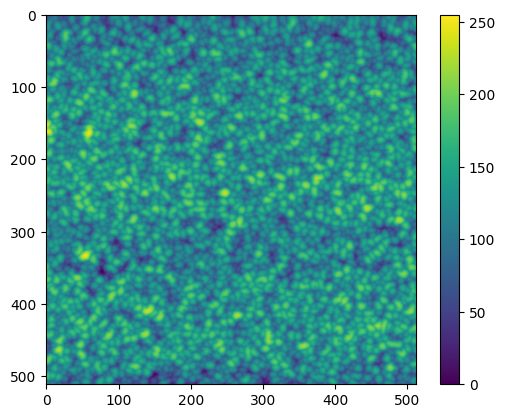

In [34]:
fig, ax = plt.subplots()
cb = ax.imshow(height_img)
plt.colorbar(cb, ax=ax)

## Linecut  
First we will take a linecut profile. This image is 4 x 4 microns, which we know from the scan size that we took on the instrument. It would be helpful to come up with a transformation axis that is in nm or microns

In [41]:
# find the number of pixels
numpix = height_img.shape[0]
# print(numpix)
px_nm = 4000. / numpix
print(f'There are {numpix} pixels in each dimension, and each pixel is {px_nm} nm')
#
nm_dimension = np.linspace(0., 4000., numpix)

There are 512 pixels in each dimension, and each pixel is 7.8125 nm


*Take notes here*

Text(0.5, 0, 'Lateral dimension (nm)')

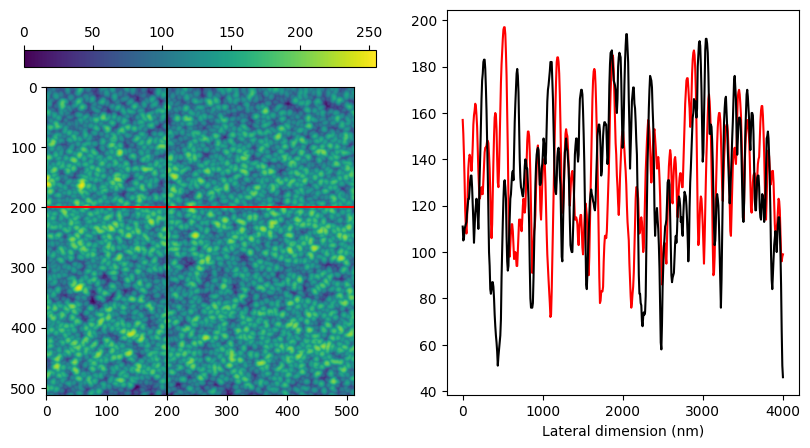

In [45]:
fig, ax = plt.subplots(1,2,figsize=(10,5))
cb = ax[0].imshow(height_img)
plt.colorbar(cb, ax=ax[0],location='top')
linecut1 = height_img[200,:]

linecut2 = height_img[:,200]
ax[1].plot(nm_dimension,linecut1,color='r')
ax[1].plot(nm_dimension,linecut2,color='k')
ax[0].axhline(200,color='r')
ax[0].axvline(200,color='k')
ax[1].set_xlabel('Lateral dimension (nm)')

### Now, we will walk through how to calculate the RMS for a given linecut.

## Fourier transforming

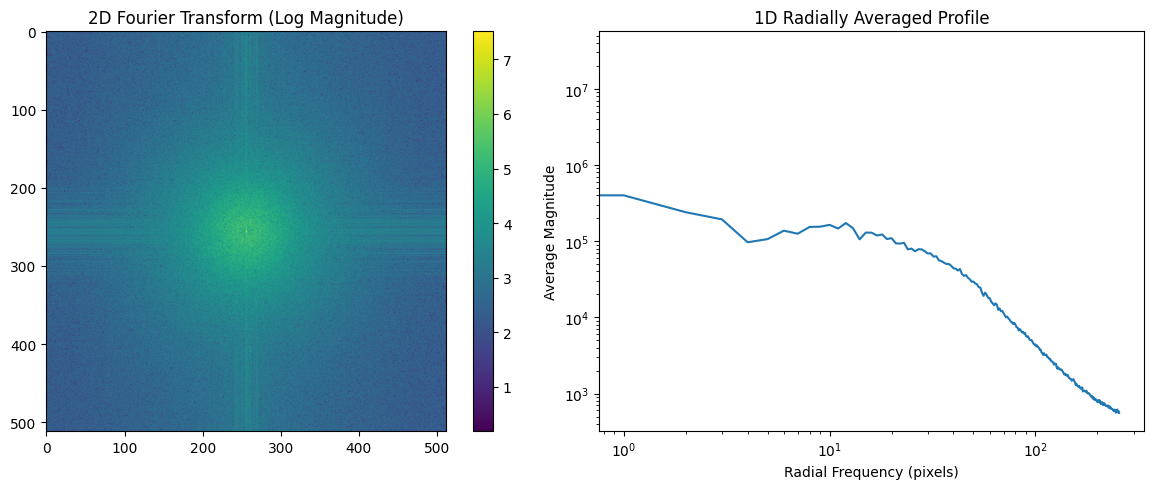

In [54]:
from scipy.fft import fft2, fftshift

# 1. Perform 2D FFT and shift the low frequencies to the center
fft_2d = fftshift(fft2(height_img))
fft_magnitude = np.abs(fft_2d)

# 2. Set up the 2D coordinates to perform radial averaging
h, w = height_img.shape
y, x = np.indices((h, w))
center = (h // 2, w // 2)
r = np.sqrt((x - center[1])**2 + (y - center[0])**2)

# Bin the radial values to compute 1D average
r_int = r.astype(int)
tbin = np.bincount(r_int.ravel(), fft_magnitude.ravel())
count = np.bincount(r_int.ravel())
# Avoid division by zero
count[count == 0] = 1
radial_profile_1d = tbin / count

# 3. Plot the results
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot the 2D FFT image (log-scaled to handle wide intensity variations)
im = ax[0].imshow(np.log10(fft_magnitude + 1), cmap='viridis')
ax[0].set_title('2D Fourier Transform (Log Magnitude)')
fig.colorbar(im, ax=ax[0])

# Plot the 1D Radially Averaged Profile
ax[1].plot(radial_profile_1d[:h//2])
ax[1].set_xlabel('Radial Frequency (pixels)')
ax[1].set_ylabel('Average Magnitude')
ax[1].set_title('1D Radially Averaged Profile')
ax[1].set_yscale('log'); ax[1].set_xscale('log')

plt.tight_layout()
plt.show()

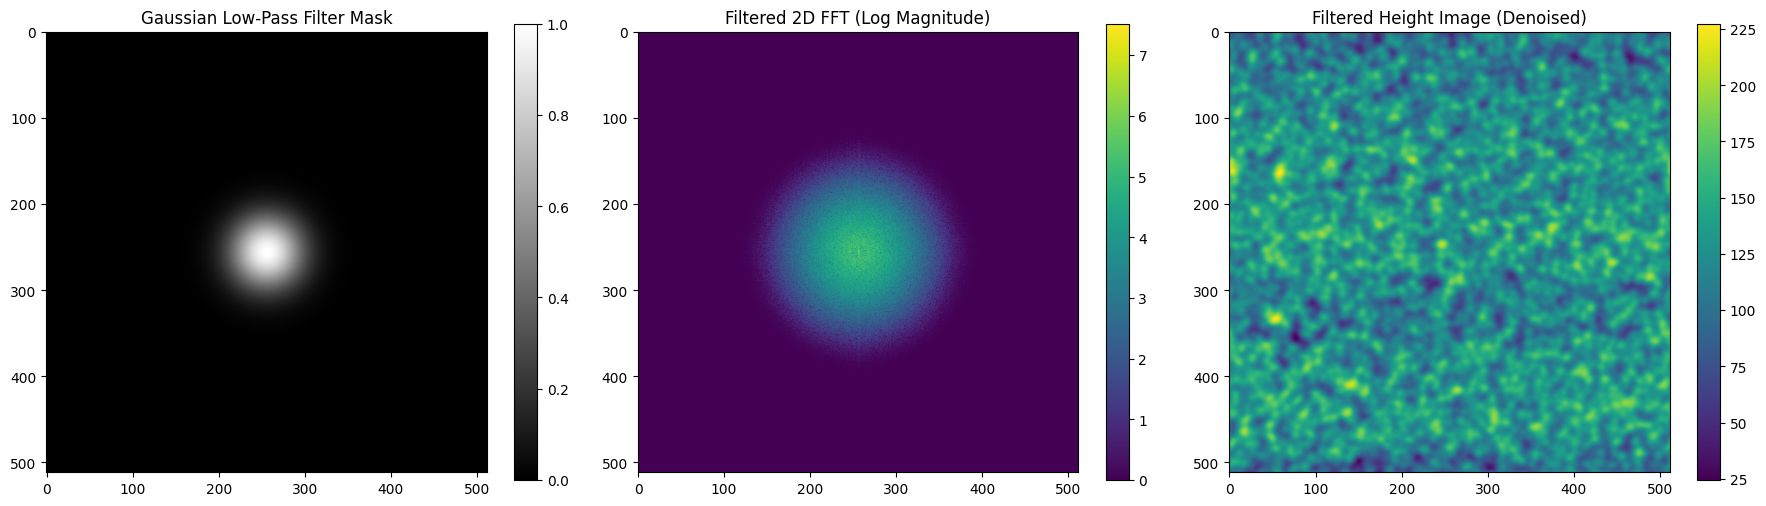

In [55]:
from scipy.fft import ifft2, ifftshift

# Define the filter radius (standard deviation of the Gaussian filter in pixels)
sigma = 30.0

# Create a 2D Gaussian low-pass filter centered at the image middle
h, w = height_img.shape
y, x = np.indices((h, w))
center = (h // 2, w // 2)
r2 = (x - center[1])**2 + (y - center[0])**2
low_pass_filter = np.exp(-r2 / (2 * sigma**2))

# Apply the low-pass filter to the shifted FFT
filtered_fft_2d = fft_2d * low_pass_filter
filtered_fft_magnitude = np.abs(filtered_fft_2d)

# Perform the Inverse FFT to transform back to the spatial domain
filtered_img = np.real(ifft2(ifftshift(filtered_fft_2d)))

# Plot original vs. filtered results
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. Plot the Low-Pass Filter in the Fourier domain
im0 = ax[0].imshow(low_pass_filter, cmap='gray')
ax[0].set_title('Gaussian Low-Pass Filter Mask')
fig.colorbar(im0, ax=ax[0])

# 2. Plot the Filtered FFT Magnitude
im1 = ax[1].imshow(np.log10(filtered_fft_magnitude + 1), cmap='viridis')
ax[1].set_title('Filtered 2D FFT (Log Magnitude)')
fig.colorbar(im1, ax=ax[1])

# 3. Plot the Cleaned (Filtered) Height Image
im2 = ax[2].imshow(filtered_img, cmap='viridis')
ax[2].set_title('Filtered Height Image (Denoised)')
fig.colorbar(im2, ax=ax[2])

plt.tight_layout()
plt.show()